In [23]:
%load_ext autoreload
%autoreload 2

from ble import get_ble_controller
from base_ble import LOG
from cmd_types import CMD
import time
import numpy as np
import pickle
import matplotlib.pyplot as plt

LOG.propagate = False

ble = get_ble_controller()
ble.connect()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
2026-05-05 11:48:53,771 | INFO     |: Looking for Artemis Nano Peripheral Device: c0:81:c4:22:a9:64
2026-05-05 11:48:53,772 | INFO     |: Scanning for device with address: c0:81:c4:22:a9:64, service UUID: 789d254e-2393-4828-b10b-3952b9ca360b
2026-05-05 11:49:03,797 | INFO     |: Found 1 device(s) advertising service 789d254e-2393-4828-b10b-3952b9ca360b
2026-05-05 11:49:03,799 | INFO     |: Selecting device: 916E591F-7011-B7AC-55D0-A23622AFF175 (name: Artemis BLE)
2026-05-05 11:49:05,156 | INFO     |: Connected to c0:81:c4:22:a9:64


In [24]:
# Cell 3
# 全局缓存
drift_msgs = []
drift_status_msgs = []

drift_log_active = False
drift_log_done = False
drift_run_done = False
last_drift_config = {}

def wait_flag(flag_name, timeout_s=8.0, poll_s=0.05):
    t0 = time.time()
    while time.time() - t0 < timeout_s:
        if globals()[flag_name]:
            return True
        time.sleep(poll_s)
    raise TimeoutError(f"Timed out waiting for {flag_name}")

def drift_notification_handler(uuid, byte_array):
    global drift_msgs, drift_status_msgs
    global drift_log_active, drift_log_done, drift_run_done
    
    s = ble.bytearray_to_string(byte_array).strip()
    print(s)
    
    drift_msgs.append(s)
    
    # 状态消息
    if s.startswith("DRIFT_STARTED"):
        drift_status_msgs.append(s)
        return
    
    if s.startswith("DRIFT_TURN_START"):
        drift_status_msgs.append(s)
        return
    
    if s.startswith("DRIFT_EXIT_START"):
        drift_status_msgs.append(s)
        return
    
    if s == "DRIFT_DONE":
        drift_status_msgs.append(s)
        drift_run_done = True
        return
    
    if s == "DRIFT_TIMEOUT":
        drift_status_msgs.append(s)
        drift_run_done = True
        return
    
    if s == "DRIFT_YAW_INVALID":
        drift_status_msgs.append(s)
        drift_run_done = True
        return
    
    if s == "DRIFT_STOPPED":
        drift_status_msgs.append(s)
        drift_run_done = True
        return
    
    # 日志消息
    if s == "DRIFT_BEGIN":
        drift_log_active = True
        drift_log_done = False
        return
    
    if s.startswith("DRIFT_END"):
        drift_log_active = False
        drift_log_done = True
        return

ble.start_notify(ble.uuid["RX_STRING"], drift_notification_handler)
print("Notify started")

Notify started


In [25]:
# Cell 5
# 运行一次 Drift
def start_drift(forward_pwm=150,
                trigger_mm=950,
                kp=0.8,
                ki=0.001,
                kd=0.5,
                exit_pwm=150,
                exit_ms=400):
    global drift_msgs, drift_status_msgs
    global drift_log_active, drift_log_done, drift_run_done, last_drift_config
    
    drift_msgs = []
    drift_status_msgs = []
    drift_log_active = False
    drift_log_done = False
    drift_run_done = False
    last_drift_config = {
        "forward_pwm": forward_pwm,
        "trigger_mm": trigger_mm,
        "kp": kp,
        "ki": ki,
        "kd": kd,
        "exit_pwm": exit_pwm,
        "exit_ms": exit_ms,
    }
    
    cmd_str = f"{forward_pwm}|{trigger_mm}|{kp}|{ki}|{kd}|{exit_pwm}|{exit_ms}"
    print("Sending:", cmd_str)
    ble.send_command(CMD.START_DRIFT, cmd_str)

In [42]:
start_drift(forward_pwm=130,
            trigger_mm=1250,
            kp=0.0,
            ki=0.0,
            kd=0.0,
            exit_pwm=80,
            exit_ms=1300)

wait_flag("drift_run_done", timeout_s=10.0)

Sending: 130|1250|0.0|0.0|0.0|80|1300


TimeoutError: Timed out waiting for drift_run_done

DRIFT_STARTED,130,1250,0.000,0.000,0.000,80,1300
DRIFT_TURN_START,1235.000,-59.960,125,50.000
DRIFT_EXIT_START,80,1300,63.123,-176.837
DRIFT_DONE


In [ ]:
drift_log_active = False
drift_log_done = False

ble.send_command(CMD.SEND_DRIFT_LOG, "")
wait_flag("drift_log_done", timeout_s=10.0)

In [62]:
# Cell 11
# 解析 DRIFT 日志
# Arduino 发回格式：
# DRIFT,t_ms,state,raw_tof,yaw,target_yaw,yaw_err,left_pwm,right_pwm

t_list = []
state_list = []
raw_tof_list = []
yaw_list = []
target_yaw_list = []
yaw_err_list = []
left_pwm_list = []
right_pwm_list = []

for msg in drift_msgs:
    if msg.startswith("DRIFT,"):
        parts = msg.split(",")
        if len(parts) == 9:
            t_list.append(float(parts[1]))
            state_list.append(int(parts[2]))
            raw_tof_list.append(float(parts[3]))
            yaw_list.append(float(parts[4]))
            target_yaw_list.append(float(parts[5]))
            yaw_err_list.append(float(parts[6]))
            left_pwm_list.append(float(parts[7]))
            right_pwm_list.append(float(parts[8]))

t_ms = np.array(t_list)
t = t_ms / 1000.0
state = np.array(state_list)
raw_tof_mm = np.array(raw_tof_list)
yaw_deg = np.array(yaw_list)
target_yaw_deg = np.array(target_yaw_list)
yaw_err_deg = np.array(yaw_err_list)
left_pwm = np.array(left_pwm_list)
right_pwm = np.array(right_pwm_list)

yaw0 = yaw_deg[0]
yaw_rel = yaw_deg - yaw0
yaw_rel = (yaw_rel + 180) % 360 - 180

target_yaw_rel = target_yaw_deg - yaw0
target_yaw_rel = (target_yaw_rel + 180) % 360 - 180

print("N =", len(t_ms))
if len(t_ms) > 0:
    print("t range =", t_ms[0], "to", t_ms[-1], "ms")
    print("raw_tof range =", np.min(raw_tof_mm), "to", np.max(raw_tof_mm), "mm")
    print("yaw range =", np.min(yaw_deg), "to", np.max(yaw_deg), "deg")

N = 380
t range = 10.0 to 2172.0 ms
raw_tof range = 957.0 to 3019.0 mm
yaw range = -171.683 to 171.378 deg


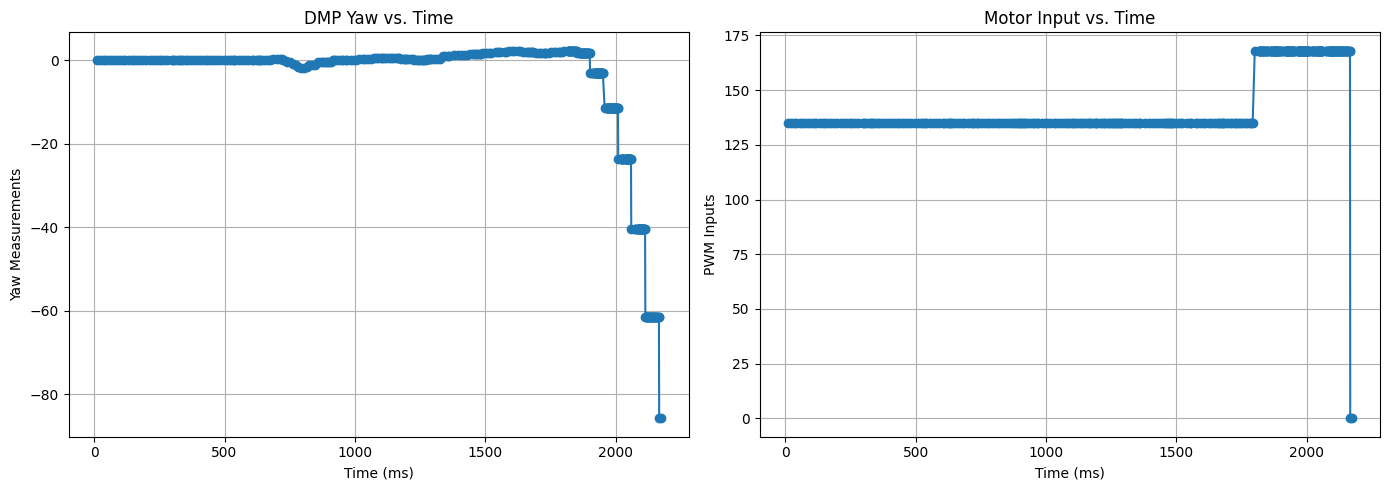

In [63]:
import numpy as np
import matplotlib.pyplot as plt

# 如果你前面已经解析好了，这几个变量应该已经存在：
# t_ms, yaw_deg, left_pwm, right_pwm

# 把 yaw 转成“相对起始角度”
yaw0 = yaw_deg[0]
yaw_rel = yaw_deg - yaw0
yaw_rel = (yaw_rel + 180) % 360 - 180

# 用一个单值来代表 motor input，方便画成和她类似的一条曲线
motor_input = np.maximum(np.abs(left_pwm), np.abs(right_pwm))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左图：DMP Yaw vs. Time
axes[0].plot(t_ms, yaw_rel, marker='o', linewidth=1.5)
axes[0].set_title("DMP Yaw vs. Time")
axes[0].set_xlabel("Time (ms)")
axes[0].set_ylabel("Yaw Measurements")
axes[0].grid(True)

# 右图：Motor Input vs. Time
axes[1].plot(t_ms, motor_input, marker='o', linewidth=1.5)
axes[1].set_title("Motor Input vs. Time")
axes[1].set_xlabel("Time (ms)")
axes[1].set_ylabel("PWM Inputs")
axes[1].grid(True)

plt.tight_layout()
plt.show()

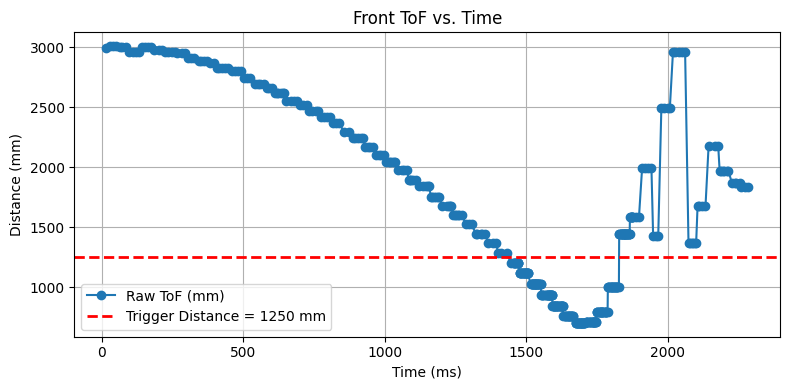

In [61]:
import matplotlib.pyplot as plt

trigger_mm = last_drift_config["trigger_mm"]

plt.figure(figsize=(8,4))
plt.plot(t_ms, raw_tof_mm, marker='o', linewidth=1.5, label='Raw ToF (mm)')
plt.axhline(trigger_mm, linestyle='--', color='red', linewidth=2, label=f'Trigger Distance = {trigger_mm} mm')
plt.xlabel("Time (ms)")
plt.ylabel("Distance (mm)")
plt.title("Front ToF vs. Time")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# 全部结束后关闭 notify
ble.stop_notify(ble.uuid["RX_STRING"])
print("Notify stopped")